# Conversión del dataset ShapeNet de PLY a BINVOX para Pix2Vox++

## Finalidad del cuaderno

Este cuaderno prepara el **ground truth tridimensional** que se utilizará en la fase de reconstrucción 3D del proyecto. Los datos originales son modelos 3D de ShapeNet almacenados como mallas `.ply`. Sin embargo, Pix2Vox++ no compara sus predicciones directamente con una malla, sino con una **rejilla voxel binaria**. Por ese motivo, cada archivo `.ply` se convierte en un archivo `model.binvox` de resolución `32 × 32 × 32`.

Un vóxel puede entenderse como el equivalente tridimensional de un píxel. Cada posición de la rejilla indica si esa zona del espacio está vacía o forma parte del objeto. Durante el entrenamiento posterior, las imágenes renderizadas del objeto serán la entrada `X` y el volumen leído desde `model.binvox` será la salida real o `y`.

Este cuaderno **no genera las imágenes**, no entrena Pix2Vox++ y no modifica ni repara las mallas originales. Su única finalidad es convertir, organizar y validar los volúmenes voxel que se emplearán como ground truth.

---

## Datos de entrada y salida

Los modelos originales se leen desde:

```text
/content/drive/MyDrive/Datos_E2/Shapenet_limpias/
└── <categoría ShapeNet>/
    └── <identificador>.ply
```

Los archivos voxelizados se guardan en:

```text
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/
└── <categoría ShapeNet>/
    └── <identificador>/
        └── model.binvox
```

Se conservan tanto el código de categoría como el identificador original de ShapeNet. De esta forma, cada volumen puede relacionarse después con su malla original y con las imágenes que se generen a partir de ella.

La conversión se realiza con BINVOX usando una resolución de `32³` y las opciones:

```text
-d 32 -cb -dc -aw
```

Estas opciones centran el modelo en el cubo voxel, emplean tallado dilatado y refuerzan la representación de partes finas. La malla `.ply` original permanece intacta.

---

## Organización del cuaderno

### 1. Preparación del entorno

Se conecta Google Drive, se instalan las dependencias gráficas necesarias para ejecutar BINVOX en Colab y se descarga el ejecutable oficial para Linux. También se comprueba que el archivo descargado sea un ejecutable válido.

### 2. Configuración y revisión del dataset

Se definen las rutas de entrada y salida, la ubicación de BINVOX y la resolución voxel. Después se recorren las carpetas de ShapeNet para construir una tabla con todos los modelos, sus categorías, identificadores y rutas.

En la ejecución final se localizaron:

- **7 categorías** de ShapeNet.
- **2.170 archivos `.ply`**.
- Entre ellos, **172 tazas**, pertenecientes a la categoría `03797390`.

### 3. Prueba inicial con una taza

Antes de procesar el conjunto completo, se selecciona una única taza. El archivo se copia temporalmente al almacenamiento local de Colab, se convierte a BINVOX y se guarda en la estructura definitiva de Google Drive.

Esta prueba permite comprobar que BINVOX puede leer correctamente las mallas PLY, que produce una rejilla `32 × 32 × 32` y que no modifica los archivos originales.

### 4. Lectura y visualización de BINVOX

Se implementa un lector compatible con la cabecera generada por BINVOX 1.38. La función:

- ignora las líneas de comentario de la cabecera;
- recupera dimensiones, traslación y escala;
- descomprime los datos almacenados mediante codificación RLE;
- devuelve una matriz booleana tridimensional.

El volumen de prueba se valida y se representa tanto en 3D como mediante sus proyecciones principales.

### 5. Función general de voxelización

Se define `voxelizar_un_modelo()`, encargada de automatizar el proceso para cualquier PLY. Para cada modelo:

1. comprueba el archivo original;
2. detecta si ya existe un BINVOX válido;
3. crea una carpeta temporal automática;
4. ejecuta BINVOX;
5. valida la rejilla generada;
6. copia `model.binvox` a Google Drive;
7. elimina automáticamente los archivos temporales.

Los archivos existentes y válidos no se regeneran cuando `SOBRESCRIBIR = False`, lo que permite reanudar una ejecución interrumpida.

### 6. Prueba con varias categorías

La función general se prueba primero con objetos pertenecientes a varias categorías. Esta etapa permite confirmar que el procedimiento no funciona únicamente con las tazas, sino con las distintas clases incluidas en el dataset.

### 7. Procesamiento completo

Se recorren los 2.170 modelos y se genera un `model.binvox` por cada `.ply`. El resultado del proceso se almacena también en:

```text
Datos_E2_voxel/voxelization_report.csv
```

La ejecución final terminó con:

- **2.170 modelos procesados**.
- **2.159 archivos generados durante la ejecución final**.
- **11 archivos que ya existían y fueron validados**.
- **0 errores**.

### 8. Compatibilidad con Pix2Vox++

Los datos BINVOX se almacenan internamente con orden de ejes `X, Z, Y`. El lector utilizado en este cuaderno aplica la misma transposición que Pix2Vox++:

```text
X, Z, Y  →  X, Y, Z
```

Se validan todos los archivos para comprobar que:

- tienen resolución `(32, 32, 32)`;
- contienen un volumen no vacío;
- pueden descomprimirse correctamente;
- devuelven el orden de ejes esperado por Pix2Vox++;
- existe un BINVOX por cada PLY original.

Resultado de la validación final:

- **2.170 PLY originales**.
- **2.170 BINVOX encontrados**.
- **2.170 BINVOX válidos**.
- **0 BINVOX inválidos**.

El informe se guarda en:

```text
Datos_E2_voxel/binvox_validation_report.csv
```

### 9. Comprobaciones visuales aleatorias

Las últimas funciones permiten seleccionar y visualizar:

- un objeto aleatorio de todo el dataset; o
- un objeto aleatorio de una categoría concreta, por ejemplo `03797390` para las tazas.

Estas visualizaciones sirven como comprobación cualitativa de que el volumen conserva la forma reconocible del objeto.

---

## Estado del proceso

La conversión y la validación ya se han completado correctamente. Por tanto, **no es necesario volver a ejecutar el cuaderno mientras se mantenga la carpeta `Datos_E2_voxel` en Google Drive**.

Solo sería necesario repetirlo si:

- se añaden o sustituyen archivos `.ply`;
- se eliminan los BINVOX generados;
- se cambia la resolución voxel;
- se modifican las opciones de BINVOX;
- se desea reconstruir el dataset desde cero.

El siguiente paso del proyecto se realizará en otro cuaderno: generar varias imágenes PNG de cada modelo PLY. Esas imágenes actuarán como entrada del modelo, mientras que los `model.binvox` producidos aquí constituirán su ground truth tridimensional.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1 Instalar dependencias

In [ ]:
!apt-get -qq update
!apt-get -qq install -y xvfb libgl1 libglu1-mesa freeglut3-dev

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


# 2 Descargar `binvox`

In [ ]:
# Eliminar la descarga HTML incorrecta
!rm -f /content/binvox

# Descargar directamente el ejecutable Linux de 64 bits
!wget -q --show-progress \
    -O /content/binvox \
    "https://www.patrickmin.com/binvox/linux64/binvox"

# Dar permisos de ejecución
!chmod 755 /content/binvox

/content/binvox     100%[===================>]   1.29M  1.57MB/s    in 0.8s    


Info de lo que hemos descargado:

In [ ]:
!file /content/binvox
!ls -lh /content/binvox
!/content/binvox

/content/binvox: ELF 64-bit LSB executable, x86-64, version 1 (SYSV), dynamically linked, interpreter /lib64/ld-linux-x86-64.so.2, for GNU/Linux 3.2.0, BuildID[sha1]=20f30b67a8c576e2f02a8d596af049fcadfb54c8, stripped
-rwxr-xr-x 1 root root 1.3M Jun  9  2025 /content/binvox

--- [binvox] mesh voxelizer, version 1.38, build #914 on 2025/06/09 11:25:41, running on Linux
--- written by Patrick Min, 2004-2025

Error: missing model filename

Usage: binvox [-d <voxel dimension>] [-t <voxel file type>] [-c] [-v] <model filespec>
  -license: show software license
  -d: specify voxel grid size (default 256, max 512)
  -t: specify voxel file type (default binvox, also supported: hips, mira, vtk, raw, schematic, msh, nrrd)
  -c: z-buffer based carving method only
  -dc: dilated carving, stop carving 1 voxel before intersection
  -v: z-buffer based parity voting method only (default is both -c and -v)
  -e: exact voxelization (any voxel intersecting a convex polygon gets set)(does not use graphics 

# 3 Configuración

In [ ]:
from pathlib import Path

# Carpeta que contiene todas las categorías con archivos PLY
RUTA_ORIGEN = Path(
    "/content/drive/MyDrive/Datos_E2/Shapenet_limpias"
)

# Nueva carpeta donde se guardarán los archivos BINVOX
RUTA_SALIDA = Path(
    "/content/drive/MyDrive/Datos_E2/Datos_E2_voxel"
)

# Ejecutable de BINVOX descargado anteriormente
RUTA_BINVOX = Path("/content/binvox")

# Resolución que necesita Pix2Vox++
RESOLUCION = 32

# Crear la carpeta principal de salida si todavía no existe
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

print("Carpeta de origen:")
print(RUTA_ORIGEN)

print("\nCarpeta de salida:")
print(RUTA_SALIDA)

print("\nEjecutable BINVOX:")
print(RUTA_BINVOX)

print("\nResolución voxel:")
print(f"{RESOLUCION} x {RESOLUCION} x {RESOLUCION}")

Carpeta de origen:
/content/drive/MyDrive/Datos_E2/Shapenet_limpias

Carpeta de salida:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel

Ejecutable BINVOX:
/content/binvox

Resolución voxel:
32 x 32 x 32


In [ ]:
from pathlib import Path
import pandas as pd

# Comprobar que la ruta de origen está definida
if "RUTA_ORIGEN" not in globals():
    RUTA_ORIGEN = Path(
        "/content/drive/MyDrive/Datos_E2/Shapenet_limpias"
    )

if not RUTA_ORIGEN.exists():
    raise FileNotFoundError(
        f"No existe la carpeta de origen:\n{RUTA_ORIGEN}"
    )

modelos_ply = []

# Recorrer las carpetas situadas directamente dentro de Shapenet_limpias
for carpeta_categoria in sorted(RUTA_ORIGEN.iterdir()):

    # Ignorar archivos sueltos
    if not carpeta_categoria.is_dir():
        continue

    categoria = carpeta_categoria.name

    # Recorrer todos los PLY de la categoría
    for ruta_ply in sorted(carpeta_categoria.glob("*.ply")):

        modelos_ply.append(
            {
                "categoria": categoria,
                "identificador": ruta_ply.stem,
                "nombre_archivo": ruta_ply.name,
                "ruta_ply": str(ruta_ply)
            }
        )

# Convertir el listado en un DataFrame
df_modelos = pd.DataFrame(modelos_ply)

if df_modelos.empty:
    raise RuntimeError(
        "No se ha encontrado ningún archivo .ply "
        f"dentro de:\n{RUTA_ORIGEN}"
    )

print("Número total de modelos encontrados:", len(df_modelos))
print("Número de categorías:", df_modelos["categoria"].nunique())

display(df_modelos.head())

Número total de modelos encontrados: 2170
Número de categorías: 7


,categoria,identificador,nombre_archivo,ruta_ply
0,02747177,10839d0dc35c94fcf4fb4dee5181bee,10839d0dc35c94fcf4fb4dee5181bee.ply,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...
1,02747177,11d2b7d8c377632bd4d8765e3910f617,11d2b7d8c377632bd4d8765e3910f617.ply,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...
2,02747177,126ae26edcd76f27ad5067eac75a07f7,126ae26edcd76f27ad5067eac75a07f7.ply,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...
3,02747177,12c4048e0d2f26a763b2acb037dfbcde,12c4048e0d2f26a763b2acb037dfbcde.ply,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...
4,02747177,1532546ac3d8a2cff155d75bbf62b80,1532546ac3d8a2cff155d75bbf62b80.ply,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...


## 3.1 Comprobación carpetas

In [ ]:
if not RUTA_ORIGEN.exists():
    raise FileNotFoundError(
        f"No existe la carpeta de origen:\n{RUTA_ORIGEN}"
    )

# Solo se consideran categorías las carpetas situadas directamente
# dentro de Shapenet_limpias
carpetas_categorias = sorted(
    carpeta
    for carpeta in RUTA_ORIGEN.iterdir()
    if carpeta.is_dir()
)

if len(carpetas_categorias) == 0:
    raise RuntimeError(
        "No se han encontrado carpetas de categorías."
    )

resumen_categorias = []
total_ply = 0

for carpeta_categoria in carpetas_categorias:
    archivos_ply = sorted(carpeta_categoria.glob("*.ply"))
    cantidad = len(archivos_ply)

    resumen_categorias.append(
        {
            "categoria": carpeta_categoria.name,
            "cantidad_ply": cantidad
        }
    )

    total_ply += cantidad

print("Número de categorías:", len(carpetas_categorias))
print("Número total de archivos PLY:", total_ply)

Número de categorías: 7
Número total de archivos PLY: 2170


In [ ]:
import pandas as pd

df_categorias = pd.DataFrame(resumen_categorias)

df_categorias

# Tazas es 03797390, tenemos 172 tazas

,categoria,cantidad_ply
0,02747177,277
1,02876657,453
2,02880940,146
3,02946921,88
4,03593526,545
5,03797390,172
6,03991062,489


# 4 Probamos con una taza

In [ ]:
CATEGORIA_PRUEBA = "03797390"

modelos_tazas = df_modelos[
    df_modelos["categoria"] == CATEGORIA_PRUEBA
].reset_index(drop=True)

if modelos_tazas.empty:
    raise RuntimeError(
        f"No se encontraron modelos en la categoría {CATEGORIA_PRUEBA}"
    )

# Seleccionar la primera taza de la tabla
modelo_prueba = modelos_tazas.iloc[0]

categoria_prueba = modelo_prueba["categoria"]
identificador_prueba = modelo_prueba["identificador"]
ruta_ply_prueba = Path(modelo_prueba["ruta_ply"])

print("Categoría:", categoria_prueba)
print("Identificador:", identificador_prueba)
print("Archivo PLY:", ruta_ply_prueba.name)
print("Ruta completa:", ruta_ply_prueba)

Categoría: 03797390
Identificador: 1038e4eac0e18dcce02ae6d2a21d494a
Archivo PLY: 1038e4eac0e18dcce02ae6d2a21d494a.ply
Ruta completa: /content/drive/MyDrive/Datos_E2/Shapenet_limpias/03797390/1038e4eac0e18dcce02ae6d2a21d494a.ply


In [ ]:
carpeta_salida_prueba = (
    RUTA_SALIDA
    / categoria_prueba
    / identificador_prueba
)

ruta_binvox_final = (
    carpeta_salida_prueba
    / "model.binvox"
)

carpeta_salida_prueba.mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta de salida:")
print(carpeta_salida_prueba)

print("\nArchivo BINVOX final:")
print(ruta_binvox_final)

Carpeta de salida:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/03797390/1038e4eac0e18dcce02ae6d2a21d494a

Archivo BINVOX final:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/03797390/1038e4eac0e18dcce02ae6d2a21d494a/model.binvox


Se copia temporalmente el .ply desde Google Drive al almacenamiento local de Colab. Esto evita ejecutar BINVOX directamente sobre Drive y hace el proceso más rápido y estable. El archivo original permanece intacto.

In [ ]:
import shutil

CARPETA_TEMPORAL = Path("/content/prueba_binvox")

# Borrar una prueba anterior, si existiera
if CARPETA_TEMPORAL.exists():
    shutil.rmtree(CARPETA_TEMPORAL)

CARPETA_TEMPORAL.mkdir(
    parents=True,
    exist_ok=True
)

# Dentro de la carpeta temporal lo llamamos model.ply
ruta_ply_temporal = CARPETA_TEMPORAL / "model.ply"

shutil.copy2(
    ruta_ply_prueba,
    ruta_ply_temporal
)

print("PLY original:")
print(ruta_ply_prueba)

print("\nCopia temporal:")
print(ruta_ply_temporal)

print("\nExiste la copia:", ruta_ply_temporal.exists())

PLY original:
/content/drive/MyDrive/Datos_E2/Shapenet_limpias/03797390/1038e4eac0e18dcce02ae6d2a21d494a.ply

Copia temporal:
/content/prueba_binvox/model.ply

Existe la copia: True


Se ejecuta BINVOX para convertir la malla de prueba en una rejilla voxel de 32×32×32. La malla original no se repara ni se sobrescribe.

Utilizaremos estas opciones:

* -d 32: resolución 32³;
* -cb: centra el objeto dentro del cubo voxel;
* -dc: realiza un tallado dilatado, deteniéndose un vóxel antes de la superficie;
* -aw: incluye las aristas durante la voxelización, ayudando a conservar partes finas como el asa;
* -t binvox: guarda el resultado en formato .binvox.



In [ ]:
import subprocess

comando_binvox = [
    "xvfb-run",
    "-a",
    str(RUTA_BINVOX),
    "-d",
    str(RESOLUCION),
    "-cb",
    "-dc",
    "-aw",
    "-t",
    "binvox",
    str(ruta_ply_temporal)
]

print("Comando que se va a ejecutar:\n")
print(" ".join(comando_binvox))

resultado = subprocess.run(
    comando_binvox,
    cwd=CARPETA_TEMPORAL,
    capture_output=True,
    text=True
)

print("\nCódigo de salida:", resultado.returncode)

print("\nSalida de BINVOX:")
print(resultado.stdout)

if resultado.stderr:
    print("\nMensajes adicionales:")
    print(resultado.stderr)

Comando que se va a ejecutar:

xvfb-run -a /content/binvox -d 32 -cb -dc -aw -t binvox /content/prueba_binvox/model.ply

Código de salida: 0

Salida de BINVOX:

--- [binvox] mesh voxelizer, version 1.38, build #914 on 2025/06/09 11:25:41, running on Linux
--- written by Patrick Min, 2004-2025

  centering model inside unit cube
  using dilated carving
  will also do wireframe rendering
parameter string [ -d 32 -cb -dc -aw -t binvox /content/prueba_binvox/model.ply]
loading model file...
MeshFileIdentifier::*create_mesh_file(/content/prueba_binvox/model.ply)
PlyMeshFile::load(/content/prueba_binvox/model.ply)
Timer [load] started
  version: 1
  file type: 3
  nr_elems: 2
  reading element [vertex], count 1752
  number of element properties: 5
load_vcg_colours: 0
  reading element [face], count 2576
  number of element properties: 1
  comment 0: https://github.com/mikedh/trimesh
Done, read 1752 vertices, 2576 faces, and 0 materials
Timer [load] stopped at 0.002368 seconds
Mesh memory use

In [ ]:
ruta_binvox_temporal = (
    CARPETA_TEMPORAL
    / "model.binvox"
)

if resultado.returncode != 0:
    raise RuntimeError(
        "BINVOX terminó con un código de error.\n"
        f"Código: {resultado.returncode}\n"
        f"Salida: {resultado.stdout}\n"
        f"Error: {resultado.stderr}"
    )

if not ruta_binvox_temporal.exists():
    raise FileNotFoundError(
        "BINVOX terminó, pero no se encontró el archivo:\n"
        f"{ruta_binvox_temporal}"
    )

tamano_bytes = ruta_binvox_temporal.stat().st_size

print("BINVOX generado correctamente.")
print("Ruta temporal:", ruta_binvox_temporal)
print("Tamaño en bytes:", tamano_bytes)

BINVOX generado correctamente.
Ruta temporal: /content/prueba_binvox/model.binvox
Tamaño en bytes: 2616


In [ ]:
shutil.copy2(
    ruta_binvox_temporal,
    ruta_binvox_final
)

if not ruta_binvox_final.exists():
    raise FileNotFoundError(
        "No se ha podido guardar el BINVOX en Google Drive."
    )

print("BINVOX guardado correctamente en Drive.")
print("Ruta final:")
print(ruta_binvox_final)

print("\nTamaño final en bytes:")
print(ruta_binvox_final.stat().st_size)

BINVOX guardado correctamente en Drive.
Ruta final:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/03797390/1038e4eac0e18dcce02ae6d2a21d494a/model.binvox

Tamaño final en bytes:
2616


In [ ]:
print("Contenido de la carpeta del modelo:\n")

for archivo in carpeta_salida_prueba.iterdir():
    print(
        archivo.name,
        "-",
        archivo.stat().st_size,
        "bytes"
    )

Contenido de la carpeta del modelo:

model.binvox - 2616 bytes


Seguimos probando, ahora para ver como se leen:

Se define una función que lee un archivo .binvox, interpreta su cabecera y descomprime los datos voxel almacenados mediante codificación RLE. La función devuelve una matriz tridimensional booleana compatible con la convención habitual de Pix2Vox.

El archivo BINVOX no contiene directamente los 32768 valores uno detrás de otro. Los comprime por parejas:

valor, número de repeticiones

Por ejemplo:

*   0, 20
*   1, 5
*   0, 100

significa:

*   20 vóxeles vacíos;
*   5 vóxeles ocupados;
*   100 vóxeles vacíos.

In [ ]:
import numpy as np
from pathlib import Path


def leer_binvox(ruta_binvox):
    """
    Lee un archivo BINVOX y devuelve:

    - volumen: matriz booleana con orden X, Y, Z
    - dimensiones: dimensiones declaradas en la cabecera
    - translate: traslación registrada por BINVOX
    - scale: escala registrada por BINVOX
    """

    ruta_binvox = Path(ruta_binvox)

    dimensiones = None
    translate = None
    scale = None

    with open(ruta_binvox, "rb") as archivo:

        # Comprobar la primera línea
        primera_linea = archivo.readline().strip()

        if not primera_linea.startswith(b"#binvox"):
            raise ValueError(
                "El archivo no tiene una cabecera BINVOX válida."
            )

        # Leer la cabecera hasta encontrar la línea "data"
        while True:

            linea = archivo.readline()

            if not linea:
                raise ValueError(
                    "El archivo terminó antes de encontrar la línea 'data'."
                )

            linea = linea.strip()

            # Ignorar líneas vacías
            if not linea:
                continue

            # Ignorar comentarios adicionales
            if linea.startswith(b"#"):
                continue

            partes = linea.split()
            nombre_campo = partes[0]

            if nombre_campo == b"dim":

                dimensiones = tuple(
                    int(valor)
                    for valor in partes[1:]
                )

            elif nombre_campo == b"translate":

                translate = tuple(
                    float(valor)
                    for valor in partes[1:]
                )

            elif nombre_campo == b"scale":

                scale = float(partes[1])

            elif nombre_campo == b"data":

                break

        # Leer los datos binarios que quedan después de "data"
        datos_comprimidos = np.frombuffer(
            archivo.read(),
            dtype=np.uint8
        )

    # Comprobar que la cabecera estaba completa
    if dimensiones is None:
        raise ValueError(
            "No se encontraron las dimensiones en la cabecera."
        )

    if translate is None:
        raise ValueError(
            "No se encontró la traslación en la cabecera."
        )

    if scale is None:
        raise ValueError(
            "No se encontró la escala en la cabecera."
        )

    if len(dimensiones) != 3:
        raise ValueError(
            f"Dimensiones BINVOX incorrectas: {dimensiones}"
        )

    # BINVOX almacena parejas:
    # valor, número de repeticiones
    if len(datos_comprimidos) == 0:
        raise ValueError(
            "El archivo no contiene datos voxel."
        )

    if len(datos_comprimidos) % 2 != 0:
        raise ValueError(
            "Los datos comprimidos BINVOX están incompletos."
        )

    valores = datos_comprimidos[::2]
    repeticiones = datos_comprimidos[1::2]

    # Solo debería haber valores 0 y 1
    if not np.all(np.isin(valores, [0, 1])):
        raise ValueError(
            "El BINVOX contiene valores distintos de 0 y 1."
        )

    # Descomprimir los datos RLE
    datos_descomprimidos = np.repeat(
        valores,
        repeticiones
    )

    numero_esperado = int(
        np.prod(dimensiones)
    )

    if len(datos_descomprimidos) != numero_esperado:
        raise ValueError(
            "El número de vóxeles descomprimidos no coincide "
            "con las dimensiones de la cabecera.\n"
            f"Esperados: {numero_esperado}\n"
            f"Obtenidos: {len(datos_descomprimidos)}"
        )

    # Los datos de BINVOX se interpretan inicialmente como X, Z, Y
    volumen_xzy = datos_descomprimidos.reshape(+
        dimensiones
    )

    # Cambiar al orden X, Y, Z
    volumen_xyz = np.transpose(
        volumen_xzy,
        (0, 2, 1)
    )

    # Convertir:
    # False = vacío
    # True = ocupado
    volumen_xyz = volumen_xyz.astype(bool)

    return {
        "volumen": volumen_xyz,
        "dimensiones": dimensiones,
        "translate": translate,
        "scale": scale
    }

In [ ]:
datos_binvox = leer_binvox(
    ruta_binvox_final
)

volumen_prueba = datos_binvox["volumen"]

print("Dimensiones indicadas en la cabecera:")
print(datos_binvox["dimensiones"])

print("\nShape de la matriz cargada:")
print(volumen_prueba.shape)

print("\nTipo de datos:")
print(volumen_prueba.dtype)

print("\nNúmero total de posiciones:")
print(volumen_prueba.size)

print("\nVóxeles ocupados:")
print(int(volumen_prueba.sum()))

print("\nPorcentaje de ocupación:")
print(f"{volumen_prueba.mean() * 100:.2f}%")

print("\nTraslación registrada por BINVOX:")
print(datos_binvox["translate"])

print("\nEscala registrada por BINVOX:")
print(datos_binvox["scale"])

Dimensiones indicadas en la cabecera:
(32, 32, 32)

Shape de la matriz cargada:
(32, 32, 32)

Tipo de datos:
bool

Número total de posiciones:
32768

Vóxeles ocupados:
9619

Porcentaje de ocupación:
29.35%

Traslación registrada por BINVOX:
(-0.370542, -0.36939, -0.565301)

Escala registrada por BINVOX:
1.0


In [ ]:
shape_esperada = (
    RESOLUCION,
    RESOLUCION,
    RESOLUCION
)

if volumen_prueba.shape != shape_esperada:
    raise ValueError(
        "La resolución del volumen es incorrecta.\n"
        f"Esperada: {shape_esperada}\n"
        f"Obtenida: {volumen_prueba.shape}"
    )

if volumen_prueba.dtype != bool:
    raise TypeError(
        f"El volumen debería ser booleano, no {volumen_prueba.dtype}."
    )

if volumen_prueba.sum() == 0:
    raise ValueError(
        "El volumen está vacío."
    )

if volumen_prueba.sum() == volumen_prueba.size:
    raise ValueError(
        "Todos los vóxeles están ocupados, lo que no sería normal."
    )

print("Validación correcta.")
print("El archivo puede leerse como una matriz voxel 32 x 32 x 32.")

Validación correcta.
El archivo puede leerse como una matriz voxel 32 x 32 x 32.


## Resultados 1 taza

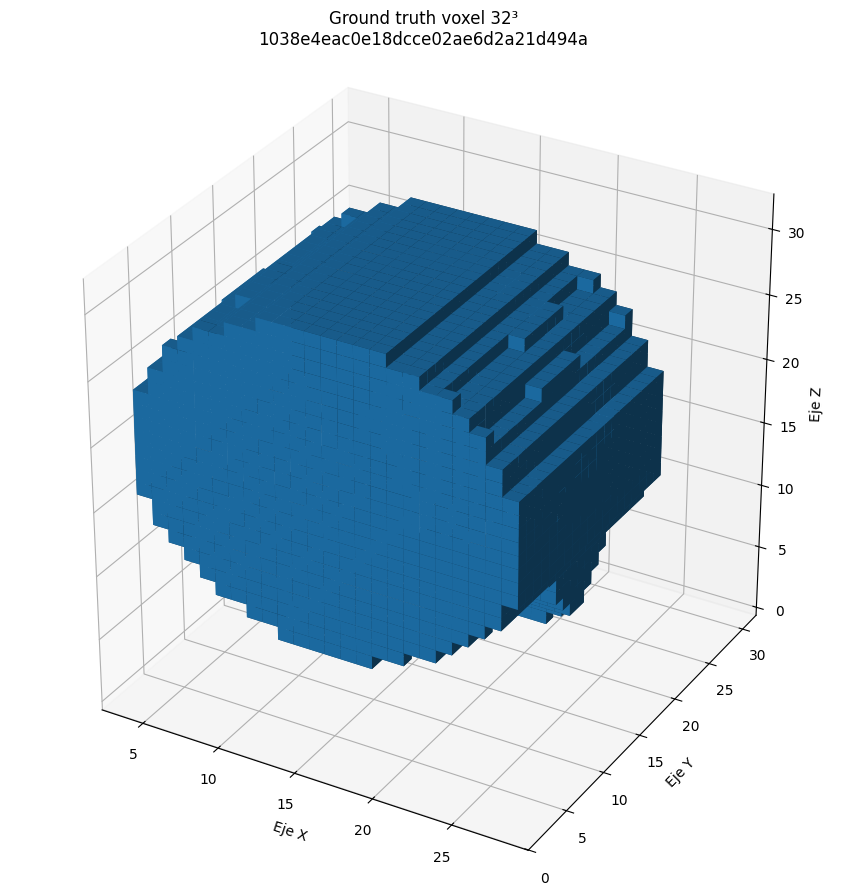

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.voxels(
    volumen_prueba
)

ax.set_title(
    f"Ground truth voxel 32³\n{identificador_prueba}"
)

ax.set_xlabel("Eje X")
ax.set_ylabel("Eje Y")
ax.set_zlabel("Eje Z")

ax.set_box_aspect((1, 1, 1))

plt.tight_layout()
plt.show()

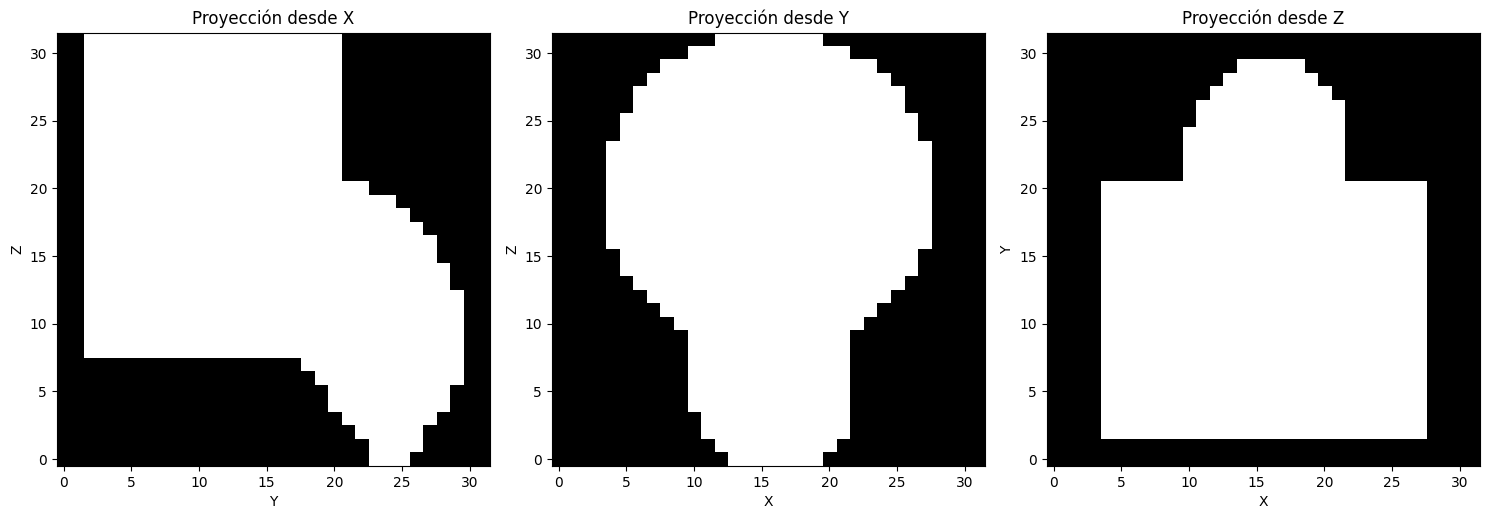

In [ ]:
proyeccion_x = volumen_prueba.max(axis=0)
proyeccion_y = volumen_prueba.max(axis=1)
proyeccion_z = volumen_prueba.max(axis=2)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    proyeccion_x.T,
    origin="lower",
    cmap="gray"
)
axes[0].set_title("Proyección desde X")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Z")

axes[1].imshow(
    proyeccion_y.T,
    origin="lower",
    cmap="gray"
)
axes[1].set_title("Proyección desde Y")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")

axes[2].imshow(
    proyeccion_z.T,
    origin="lower",
    cmap="gray"
)
axes[2].set_title("Proyección desde Z")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")

plt.tight_layout()
plt.show()

# Función para voxelizar un único modelo

In [ ]:
# Si es False, no se vuelven a generar los BINVOX ya existentes y válidos
SOBRESCRIBIR = False

# Tiempo máximo permitido para voxelizar un único modelo
TIMEOUT_BINVOX = 180

print("Sobrescribir archivos existentes:", SOBRESCRIBIR)
print("Tiempo máximo por modelo:", TIMEOUT_BINVOX, "segundos")

Sobrescribir archivos existentes: False
Tiempo máximo por modelo: 180 segundos


Se define una función reutilizable que recibe un archivo .ply, su categoría y su identificador. La función copia temporalmente el PLY al almacenamiento local de Colab, ejecuta BINVOX, valida el volumen generado y guarda el resultado en Google Drive. La carpeta temporal se elimina automáticamente al terminar.

In [ ]:
import shutil
import subprocess
import tempfile
from pathlib import Path


def voxelizar_un_modelo(
    ruta_ply,
    categoria,
    identificador,
    sobrescribir=False
):
    """
    Convierte un archivo PLY en un model.binvox de 32x32x32.

    Devuelve un diccionario con el resultado del procesamiento.
    """

    ruta_ply = Path(ruta_ply)
    categoria = str(categoria)
    identificador = str(identificador)

    # Ruta definitiva del ground truth
    carpeta_salida_modelo = (
        RUTA_SALIDA
        / categoria
        / identificador
    )

    ruta_binvox_final = (
        carpeta_salida_modelo
        / "model.binvox"
    )

    try:

        # ------------------------------------------------------------
        # 1. Comprobar el archivo PLY
        # ------------------------------------------------------------

        if not ruta_ply.exists():
            raise FileNotFoundError(
                f"No existe el PLY: {ruta_ply}"
            )

        # ------------------------------------------------------------
        # 2. Comprobar si ya existe un BINVOX válido
        # ------------------------------------------------------------

        if ruta_binvox_final.exists() and not sobrescribir:

            try:
                datos_existentes = leer_binvox(
                    ruta_binvox_final
                )

                volumen_existente = datos_existentes["volumen"]

                if volumen_existente.shape != (
                    RESOLUCION,
                    RESOLUCION,
                    RESOLUCION
                ):
                    raise ValueError(
                        f"Shape incorrecta: {volumen_existente.shape}"
                    )

                if int(volumen_existente.sum()) == 0:
                    raise ValueError(
                        "El volumen existente está vacío."
                    )

                return {
                    "categoria": categoria,
                    "identificador": identificador,
                    "ruta_ply": str(ruta_ply),
                    "ruta_binvox": str(ruta_binvox_final),
                    "estado": "existente_valido",
                    "voxeles_ocupados": int(
                        volumen_existente.sum()
                    ),
                    "porcentaje_ocupacion": float(
                        volumen_existente.mean() * 100
                    ),
                    "dimensiones": str(
                        volumen_existente.shape
                    ),
                    "error": None
                }

            except Exception:

                # Si existe pero no es válido, se elimina y se regenera
                ruta_binvox_final.unlink()

        # ------------------------------------------------------------
        # 3. Crear una carpeta temporal automática
        # ------------------------------------------------------------

        with tempfile.TemporaryDirectory(
            prefix="binvox_",
            dir="/content"
        ) as carpeta_temporal:

            carpeta_temporal = Path(carpeta_temporal)

            ruta_ply_temporal = (
                carpeta_temporal
                / "model.ply"
            )

            ruta_binvox_temporal = (
                carpeta_temporal
                / "model.binvox"
            )

            # Copiar el PLY desde Drive al almacenamiento local
            shutil.copy2(
                ruta_ply,
                ruta_ply_temporal
            )

            # --------------------------------------------------------
            # 4. Ejecutar BINVOX
            # --------------------------------------------------------

            comando = [
                "xvfb-run",
                "-a",
                str(RUTA_BINVOX),
                "-d",
                str(RESOLUCION),
                "-cb",
                "-dc",
                "-aw",
                "-t",
                "binvox",
                str(ruta_ply_temporal)
            ]

            resultado = subprocess.run(
                comando,
                cwd=carpeta_temporal,
                capture_output=True,
                text=True,
                timeout=TIMEOUT_BINVOX
            )

            if resultado.returncode != 0:
                raise RuntimeError(
                    "BINVOX terminó con error.\n"
                    f"{resultado.stderr}\n"
                    f"{resultado.stdout[-1500:]}"
                )

            if not ruta_binvox_temporal.exists():
                raise FileNotFoundError(
                    "BINVOX terminó sin crear model.binvox."
                )

            # --------------------------------------------------------
            # 5. Validar el volumen generado
            # --------------------------------------------------------

            datos_binvox = leer_binvox(
                ruta_binvox_temporal
            )

            volumen = datos_binvox["volumen"]

            if volumen.shape != (
                RESOLUCION,
                RESOLUCION,
                RESOLUCION
            ):
                raise ValueError(
                    f"Shape incorrecta: {volumen.shape}"
                )

            if volumen.dtype != bool:
                raise TypeError(
                    f"Tipo incorrecto: {volumen.dtype}"
                )

            voxeles_ocupados = int(
                volumen.sum()
            )

            if voxeles_ocupados == 0:
                raise ValueError(
                    "El volumen generado está vacío."
                )

            if voxeles_ocupados == volumen.size:
                raise ValueError(
                    "Todos los vóxeles están ocupados."
                )

            # --------------------------------------------------------
            # 6. Guardar el resultado definitivo
            # --------------------------------------------------------

            carpeta_salida_modelo.mkdir(
                parents=True,
                exist_ok=True
            )

            shutil.copy2(
                ruta_binvox_temporal,
                ruta_binvox_final
            )

        # Al salir del bloque "with", la carpeta temporal se borra sola

        if not ruta_binvox_final.exists():
            raise FileNotFoundError(
                "No se pudo guardar el BINVOX en Drive."
            )

        return {
            "categoria": categoria,
            "identificador": identificador,
            "ruta_ply": str(ruta_ply),
            "ruta_binvox": str(ruta_binvox_final),
            "estado": "generado",
            "voxeles_ocupados": voxeles_ocupados,
            "porcentaje_ocupacion": float(
                volumen.mean() * 100
            ),
            "dimensiones": str(volumen.shape),
            "error": None
        }

    except subprocess.TimeoutExpired:

        return {
            "categoria": categoria,
            "identificador": identificador,
            "ruta_ply": str(ruta_ply),
            "ruta_binvox": str(ruta_binvox_final),
            "estado": "error",
            "voxeles_ocupados": None,
            "porcentaje_ocupacion": None,
            "dimensiones": None,
            "error": (
                f"BINVOX superó el límite de "
                f"{TIMEOUT_BINVOX} segundos."
            )
        }

    except Exception as error:

        return {
            "categoria": categoria,
            "identificador": identificador,
            "ruta_ply": str(ruta_ply),
            "ruta_binvox": str(ruta_binvox_final),
            "estado": "error",
            "voxeles_ocupados": None,
            "porcentaje_ocupacion": None,
            "dimensiones": None,
            "error": f"{type(error).__name__}: {error}"
        }

Antes de recorrer todo el dataset, se selecciona un modelo de cinco categorías diferentes. Esto permite comprobar que la función funciona no solo para tazas, sino también para otras clases de objetos.

In [ ]:
# Ordenar primero para que la selección sea reproducible
df_modelos_ordenados = df_modelos.sort_values(
    by=["categoria", "identificador"]
)

# Elegir un objeto por categoría
muestra_categorias = (
    df_modelos_ordenados
    .groupby("categoria", group_keys=False)
    .head(1)
    .head(5)
    .reset_index(drop=True)
)

print("Modelos seleccionados para la prueba:")
display(
    muestra_categorias[
        [
            "categoria",
            "identificador",
            "nombre_archivo"
        ]
    ]
)

Modelos seleccionados para la prueba:


,categoria,identificador,nombre_archivo
0,02747177,10839d0dc35c94fcf4fb4dee5181bee,10839d0dc35c94fcf4fb4dee5181bee.ply
1,02876657,109d55a137c042f5760315ac3bf2c13e,109d55a137c042f5760315ac3bf2c13e.ply
2,02880940,11547e8d8f143557525b133235812833,11547e8d8f143557525b133235812833.ply
3,02946921,100c5aee62f1c9b9f54f8416555967,100c5aee62f1c9b9f54f8416555967.ply
4,03593526,10af6bdfd126209faaf0ad030fc37d94,10af6bdfd126209faaf0ad030fc37d94.ply


In [ ]:
resultados_prueba_general = []

for fila in muestra_categorias.itertuples(index=False):

    resultado_modelo = voxelizar_un_modelo(
        ruta_ply=fila.ruta_ply,
        categoria=fila.categoria,
        identificador=fila.identificador,
        sobrescribir=SOBRESCRIBIR
    )

    resultados_prueba_general.append(
        resultado_modelo
    )

df_prueba_general = pd.DataFrame(
    resultados_prueba_general
)

display(df_prueba_general)

,categoria,identificador,ruta_ply,ruta_binvox,estado,voxeles_ocupados,porcentaje_ocupacion,dimensiones,error
0,02747177,10839d0dc35c94fcf4fb4dee5181bee,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,9094,27.752686,"(32, 32, 32)",None
1,02876657,109d55a137c042f5760315ac3bf2c13e,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,1481,4.519653,"(32, 32, 32)",None
2,02880940,11547e8d8f143557525b133235812833,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,2538,7.745361,"(32, 32, 32)",None
3,02946921,100c5aee62f1c9b9f54f8416555967,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,8742,26.678467,"(32, 32, 32)",None
4,03593526,10af6bdfd126209faaf0ad030fc37d94,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,847,2.584839,"(32, 32, 32)",None


In [ ]:
numero_errores_prueba = int(
    df_prueba_general["error"].notna().sum()
)

print(
    "Modelos probados:",
    len(df_prueba_general)
)

print(
    "Modelos correctos:",
    len(df_prueba_general) - numero_errores_prueba
)

print(
    "Modelos con error:",
    numero_errores_prueba
)

if numero_errores_prueba > 0:

    print("\nErrores encontrados:")

    display(
        df_prueba_general.loc[
            df_prueba_general["error"].notna(),
            [
                "categoria",
                "identificador",
                "error"
            ]
        ]
    )

else:

    print(
        "\nPrueba correcta: todos los modelos "
        "se han convertido a BINVOX 32³."
    )

Modelos probados: 5
Modelos correctos: 5
Modelos con error: 0

Prueba correcta: todos los modelos se han convertido a BINVOX 32³.


# Procesamos todas las categorias

In [ ]:
from tqdm.auto import tqdm

resultados_completos = []

for fila in tqdm(
    df_modelos.itertuples(index=False),
    total=len(df_modelos),
    desc="Voxelizando todos los modelos"
):

    resultado_modelo = voxelizar_un_modelo(
        ruta_ply=fila.ruta_ply,
        categoria=fila.categoria,
        identificador=fila.identificador,
        sobrescribir=SOBRESCRIBIR
    )

    resultados_completos.append(
        resultado_modelo
    )

Voxelizando todos los modelos:   0%|          | 0/2170 [00:00<?, ?it/s]

In [ ]:
df_resultados_completos = pd.DataFrame(
    resultados_completos
)

RUTA_INFORME = (
    RUTA_SALIDA
    / "voxelization_report.csv"
)

df_resultados_completos.to_csv(
    RUTA_INFORME,
    index=False
)

print("Informe guardado en:")
print(RUTA_INFORME)

display(df_resultados_completos.head())

Informe guardado en:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/voxelization_report.csv


,categoria,identificador,ruta_ply,ruta_binvox,estado,voxeles_ocupados,porcentaje_ocupacion,dimensiones,error
0,02747177,10839d0dc35c94fcf4fb4dee5181bee,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,9094,27.752686,"(32, 32, 32)",None
1,02747177,11d2b7d8c377632bd4d8765e3910f617,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,4806,14.666748,"(32, 32, 32)",None
2,02747177,126ae26edcd76f27ad5067eac75a07f7,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,7737,23.611450,"(32, 32, 32)",None
3,02747177,12c4048e0d2f26a763b2acb037dfbcde,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,4958,15.130615,"(32, 32, 32)",None
4,02747177,1532546ac3d8a2cff155d75bbf62b80,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...,existente_valido,6779,20.687866,"(32, 32, 32)",None


In [ ]:
resumen_estados = (
    df_resultados_completos["estado"]
    .value_counts()
)

print("RESUMEN DEL PROCESAMIENTO\n")

print(resumen_estados)

numero_errores = int(
    df_resultados_completos["error"]
    .notna()
    .sum()
)

print("\nNúmero total de modelos:")
print(len(df_resultados_completos))

print("\nNúmero de errores:")
print(numero_errores)

if numero_errores > 0:

    print("\nModelos con error:")

    display(
        df_resultados_completos.loc[
            df_resultados_completos["error"].notna(),
            [
                "categoria",
                "identificador",
                "ruta_ply",
                "error"
            ]
        ]
    )

else:

    print(
        "\nProceso completado sin errores."
    )

RESUMEN DEL PROCESAMIENTO

estado
generado            2159
existente_valido      11
Name: count, dtype: int64

Número total de modelos:
2170

Número de errores:
0

Proceso completado sin errores.


# Probamos que nos sirven para Pix2Vox

In [ ]:
import numpy as np
from pathlib import Path


def leer_binvox_crudo(ruta_binvox):
    """
    Lee un BINVOX conservando el orden original almacenado:

        X, Z, Y

    Esta función se utiliza solo para validar el orden de ejes.
    """

    ruta_binvox = Path(ruta_binvox)

    dimensiones = None
    translate = None
    scale = None

    with open(ruta_binvox, "rb") as archivo:

        primera_linea = archivo.readline().strip()

        if not primera_linea.startswith(b"#binvox"):
            raise ValueError(
                "El archivo no tiene una cabecera BINVOX válida."
            )

        while True:

            linea = archivo.readline()

            if not linea:
                raise ValueError(
                    "El archivo terminó antes de encontrar 'data'."
                )

            linea = linea.strip()

            # Ignorar líneas vacías y comentarios
            if not linea or linea.startswith(b"#"):
                continue

            partes = linea.split()
            campo = partes[0]

            if campo == b"dim":
                dimensiones = tuple(
                    int(valor)
                    for valor in partes[1:]
                )

            elif campo == b"translate":
                translate = tuple(
                    float(valor)
                    for valor in partes[1:]
                )

            elif campo == b"scale":
                scale = float(partes[1])

            elif campo == b"data":
                break

        datos_comprimidos = np.frombuffer(
            archivo.read(),
            dtype=np.uint8
        )

    if dimensiones is None:
        raise ValueError("No se encontraron las dimensiones.")

    if translate is None:
        raise ValueError("No se encontró la traslación.")

    if scale is None:
        raise ValueError("No se encontró la escala.")

    if len(datos_comprimidos) == 0:
        raise ValueError("El archivo no contiene datos voxel.")

    if len(datos_comprimidos) % 2 != 0:
        raise ValueError("Los datos RLE están incompletos.")

    valores = datos_comprimidos[::2]
    repeticiones = datos_comprimidos[1::2]

    if not np.all(np.isin(valores, [0, 1])):
        raise ValueError(
            "El archivo contiene valores distintos de 0 y 1."
        )

    datos_descomprimidos = np.repeat(
        valores,
        repeticiones
    )

    numero_esperado = int(np.prod(dimensiones))

    if len(datos_descomprimidos) != numero_esperado:
        raise ValueError(
            f"Se esperaban {numero_esperado} posiciones, "
            f"pero se obtuvieron {len(datos_descomprimidos)}."
        )

    # Orden original almacenado por BINVOX: X, Z, Y
    volumen_xzy = datos_descomprimidos.reshape(
        dimensiones
    ).astype(bool)

    return {
        "volumen_xzy": volumen_xzy,
        "dimensiones": dimensiones,
        "translate": translate,
        "scale": scale,
        "orden_ejes": "xzy"
    }

In [ ]:
def validar_orden_pix2vox(ruta_binvox):
    """
    Comprueba que leer_binvox() devuelve exactamente el volumen
    que espera el lector de Pix2Vox: orden X, Y, Z.
    """

    ruta_binvox = Path(ruta_binvox)

    # Lectura en el orden físico de BINVOX: X, Z, Y
    datos_crudos = leer_binvox_crudo(ruta_binvox)
    volumen_xzy = datos_crudos["volumen_xzy"]

    # Conversión esperada por Pix2Vox: X, Y, Z
    volumen_xyz_esperado = np.transpose(
        volumen_xzy,
        (0, 2, 1)
    )

    # Resultado de nuestra función habitual
    datos_lector = leer_binvox(ruta_binvox)
    volumen_xyz_obtenido = datos_lector["volumen"]

    coincide = np.array_equal(
        volumen_xyz_esperado,
        volumen_xyz_obtenido
    )

    return {
        "ruta_binvox": str(ruta_binvox),
        "shape": volumen_xyz_obtenido.shape,
        "orden_en_archivo": "xzy",
        "orden_devuelto": "xyz",
        "coincide_con_pix2vox": coincide,
        "voxeles_ocupados": int(
            volumen_xyz_obtenido.sum()
        )
    }

In [ ]:
resultado_orden = validar_orden_pix2vox(
    ruta_binvox_final
)

resultado_orden

{'ruta_binvox': '/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/03797390/1038e4eac0e18dcce02ae6d2a21d494a/model.binvox',
 'shape': (32, 32, 32),
 'orden_en_archivo': 'xzy',
 'orden_devuelto': 'xyz',
 'coincide_con_pix2vox': True,
 'voxeles_ocupados': 9619}

In [ ]:
import pandas as pd
from tqdm.auto import tqdm


rutas_binvox = sorted(
    RUTA_SALIDA.glob("*/*/model.binvox")
)

if len(rutas_binvox) == 0:
    raise RuntimeError(
        f"No se encontraron archivos model.binvox en:\n"
        f"{RUTA_SALIDA}"
    )

print("Archivos BINVOX encontrados:", len(rutas_binvox))

Archivos BINVOX encontrados: 2170


In [ ]:
resultados_validacion = []

for ruta_binvox in tqdm(
    rutas_binvox,
    desc="Validando BINVOX"
):

    categoria = ruta_binvox.parent.parent.name
    identificador = ruta_binvox.parent.name

    try:

        resultado = validar_orden_pix2vox(
            ruta_binvox
        )

        shape_correcta = (
            resultado["shape"]
            == (RESOLUCION, RESOLUCION, RESOLUCION)
        )

        volumen_no_vacio = (
            resultado["voxeles_ocupados"] > 0
        )

        orden_correcto = (
            resultado["coincide_con_pix2vox"]
        )

        valido = (
            shape_correcta
            and volumen_no_vacio
            and orden_correcto
        )

        resultados_validacion.append(
            {
                "categoria": categoria,
                "identificador": identificador,
                "ruta_binvox": str(ruta_binvox),
                "shape": str(resultado["shape"]),
                "orden_archivo": "xzy",
                "orden_pix2vox": "xyz",
                "voxeles_ocupados": (
                    resultado["voxeles_ocupados"]
                ),
                "valido": valido,
                "error": None
            }
        )

    except Exception as error:

        resultados_validacion.append(
            {
                "categoria": categoria,
                "identificador": identificador,
                "ruta_binvox": str(ruta_binvox),
                "shape": None,
                "orden_archivo": None,
                "orden_pix2vox": None,
                "voxeles_ocupados": None,
                "valido": False,
                "error": f"{type(error).__name__}: {error}"
            }
        )


df_validacion_binvox = pd.DataFrame(
    resultados_validacion
)

Validando BINVOX:   0%|          | 0/2170 [00:00<?, ?it/s]

In [ ]:
numero_ply = len(df_modelos)
numero_binvox = len(df_validacion_binvox)

numero_validos = int(
    df_validacion_binvox["valido"].sum()
)

numero_invalidos = int(
    (~df_validacion_binvox["valido"]).sum()
)

print("RESUMEN DE VALIDACIÓN\n")

print("Archivos PLY originales:", numero_ply)
print("Archivos BINVOX:", numero_binvox)
print("BINVOX válidos:", numero_validos)
print("BINVOX inválidos:", numero_invalidos)

if numero_ply == numero_binvox:
    print("\nCorrecto: hay un BINVOX por cada PLY.")
else:
    print(
        "\nAVISO: el número de PLY y BINVOX "
        "no coincide."
    )

if numero_invalidos == 0:
    print(
        "Correcto: todos los BINVOX tienen orden "
        "X-Y-Z al cargarse para Pix2Vox."
    )
else:
    print("\nArchivos con problemas:")

    display(
        df_validacion_binvox.loc[
            ~df_validacion_binvox["valido"]
        ]
    )

RESUMEN DE VALIDACIÓN

Archivos PLY originales: 2170
Archivos BINVOX: 2170
BINVOX válidos: 2170
BINVOX inválidos: 0

Correcto: hay un BINVOX por cada PLY.
Correcto: todos los BINVOX tienen orden X-Y-Z al cargarse para Pix2Vox.


In [ ]:
RUTA_VALIDACION = (
    RUTA_SALIDA
    / "binvox_validation_report.csv"
)

df_validacion_binvox.to_csv(
    RUTA_VALIDACION,
    index=False
)

print("Informe guardado en:")
print(RUTA_VALIDACION)

Informe guardado en:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/binvox_validation_report.csv


# Visualizamos unos casos aleatorios

In [ ]:
import random


def seleccionar_binvox_aleatorio(
    categoria=None,
    semilla=None
):
    """
    Selecciona un model.binvox aleatorio.

    categoria:
        - "03797390" para elegir una taza.
        - None para elegir entre todas las categorías.

    semilla:
        - None para una selección diferente cada vez.
        - Un número para obtener una selección reproducible.
    """

    if categoria is None:

        candidatos = sorted(
            RUTA_SALIDA.glob("*/*/model.binvox")
        )

        categoria_normalizada = None

    else:

        categoria_normalizada = (
            str(categoria)
            .strip()
            .zfill(8)
        )

        carpeta_categoria = (
            RUTA_SALIDA
            / categoria_normalizada
        )

        if not carpeta_categoria.exists():
            raise FileNotFoundError(
                "No existe la categoría:\n"
                f"{carpeta_categoria}"
            )

        candidatos = sorted(
            carpeta_categoria.glob(
                "*/model.binvox"
            )
        )

    if len(candidatos) == 0:
        raise RuntimeError(
            "No se encontraron BINVOX para la selección."
        )

    generador = random.Random(semilla)

    ruta_seleccionada = generador.choice(
        candidatos
    )

    categoria_seleccionada = (
        ruta_seleccionada.parent.parent.name
    )

    identificador = (
        ruta_seleccionada.parent.name
    )

    ruta_ply_original = (
        RUTA_ORIGEN
        / categoria_seleccionada
        / f"{identificador}.ply"
    )

    return {
        "categoria": categoria_seleccionada,
        "identificador": identificador,
        "ruta_binvox": ruta_seleccionada,
        "ruta_ply": ruta_ply_original
    }

In [ ]:
import matplotlib.pyplot as plt


def visualizar_binvox_aleatorio(
    categoria=None,
    semilla=None
):
    """
    Visualiza un objeto aleatorio.

    Ejemplos:
        visualizar_binvox_aleatorio("03797390")
        visualizar_binvox_aleatorio()
    """

    seleccion = seleccionar_binvox_aleatorio(
        categoria=categoria,
        semilla=semilla
    )

    datos = leer_binvox(
        seleccion["ruta_binvox"]
    )

    volumen = datos["volumen"]

    print("Categoría:", seleccion["categoria"])
    print("Identificador:", seleccion["identificador"])

    print("\nBINVOX:")
    print(seleccion["ruta_binvox"])

    print("\nPLY original:")
    print(seleccion["ruta_ply"])

    print("\nExiste el PLY:")
    print(seleccion["ruta_ply"].exists())

    print("\nShape:")
    print(volumen.shape)

    print("\nOrden cargado:")
    print("X, Y, Z")

    print("\nVóxeles ocupados:")
    print(int(volumen.sum()))

    print("\nPorcentaje de ocupación:")
    print(f"{volumen.mean() * 100:.2f}%")

    # ---------------------------------------------------------
    # Representación tridimensional
    # ---------------------------------------------------------

    fig = plt.figure(figsize=(9, 9))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    ax.voxels(volumen)

    ax.set_title(
        "Ground truth voxel 32³\n"
        f"{seleccion['categoria']} / "
        f"{seleccion['identificador']}"
    )

    ax.set_xlabel("Eje X")
    ax.set_ylabel("Eje Y")
    ax.set_zlabel("Eje Z")

    ax.set_box_aspect((1, 1, 1))

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Proyecciones principales
    # ---------------------------------------------------------

    proyeccion_x = volumen.max(axis=0)
    proyeccion_y = volumen.max(axis=1)
    proyeccion_z = volumen.max(axis=2)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        proyeccion_x.T,
        origin="lower",
        cmap="gray"
    )
    axes[0].set_title("Proyección desde X")
    axes[0].set_xlabel("Y")
    axes[0].set_ylabel("Z")

    axes[1].imshow(
        proyeccion_y.T,
        origin="lower",
        cmap="gray"
    )
    axes[1].set_title("Proyección desde Y")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Z")

    axes[2].imshow(
        proyeccion_z.T,
        origin="lower",
        cmap="gray"
    )
    axes[2].set_title("Proyección desde Z")
    axes[2].set_xlabel("X")
    axes[2].set_ylabel("Y")

    plt.tight_layout()
    plt.show()

    return seleccion

Categoría: 03797390
Identificador: 1dd8290a154f4b1534a8988fdcee4fde

BINVOX:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/03797390/1dd8290a154f4b1534a8988fdcee4fde/model.binvox

PLY original:
/content/drive/MyDrive/Datos_E2/Shapenet_limpias/03797390/1dd8290a154f4b1534a8988fdcee4fde.ply

Existe el PLY:
True

Shape:
(32, 32, 32)

Orden cargado:
X, Y, Z

Vóxeles ocupados:
13631

Porcentaje de ocupación:
41.60%


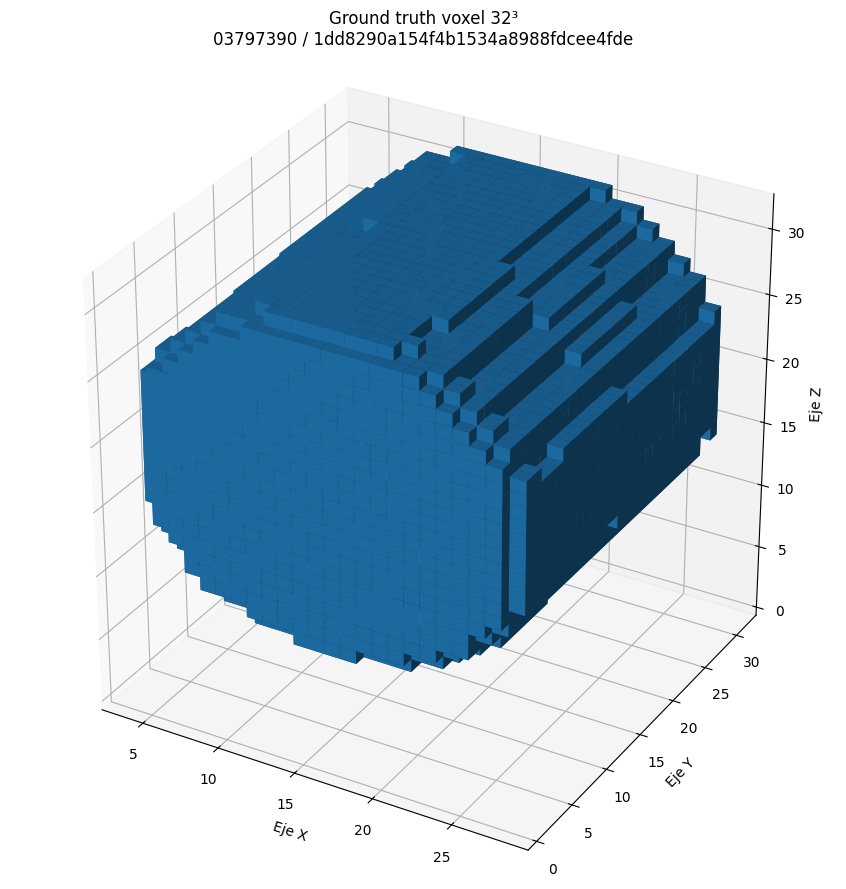

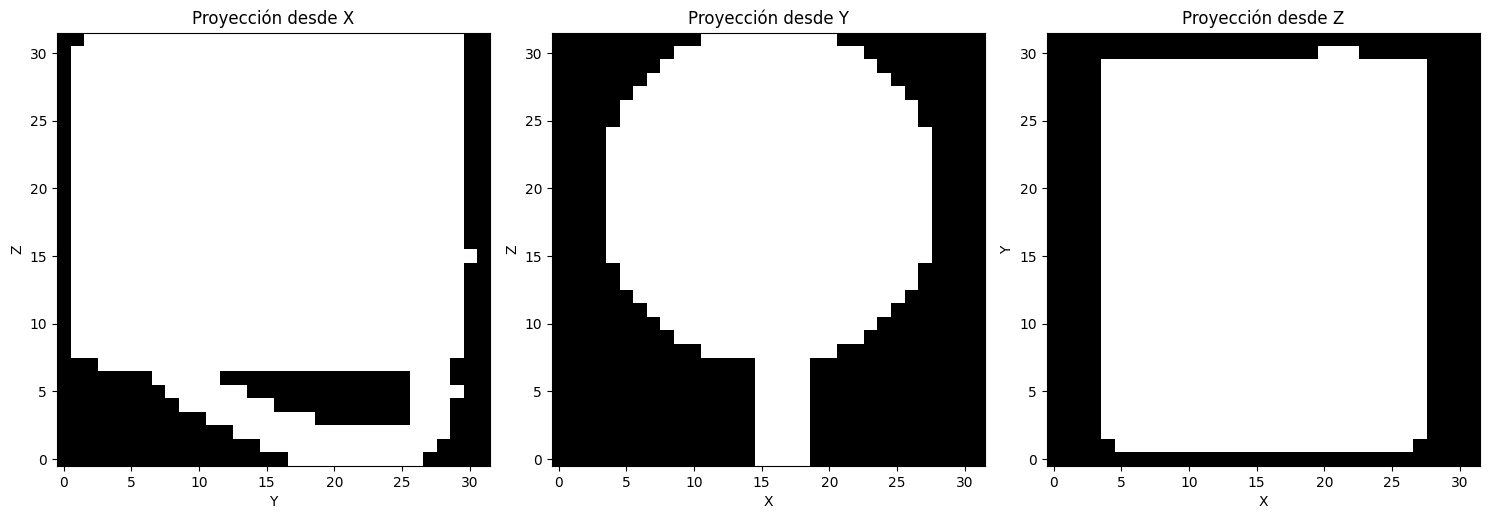

In [ ]:
seleccion = visualizar_binvox_aleatorio(
    categoria="03797390"
)

Categoría: 02876657
Identificador: 289b2ca2562277a9ca3fbd0e4ec160a5

BINVOX:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/02876657/289b2ca2562277a9ca3fbd0e4ec160a5/model.binvox

PLY original:
/content/drive/MyDrive/Datos_E2/Shapenet_limpias/02876657/289b2ca2562277a9ca3fbd0e4ec160a5.ply

Existe el PLY:
True

Shape:
(32, 32, 32)

Orden cargado:
X, Y, Z

Vóxeles ocupados:
4364

Porcentaje de ocupación:
13.32%


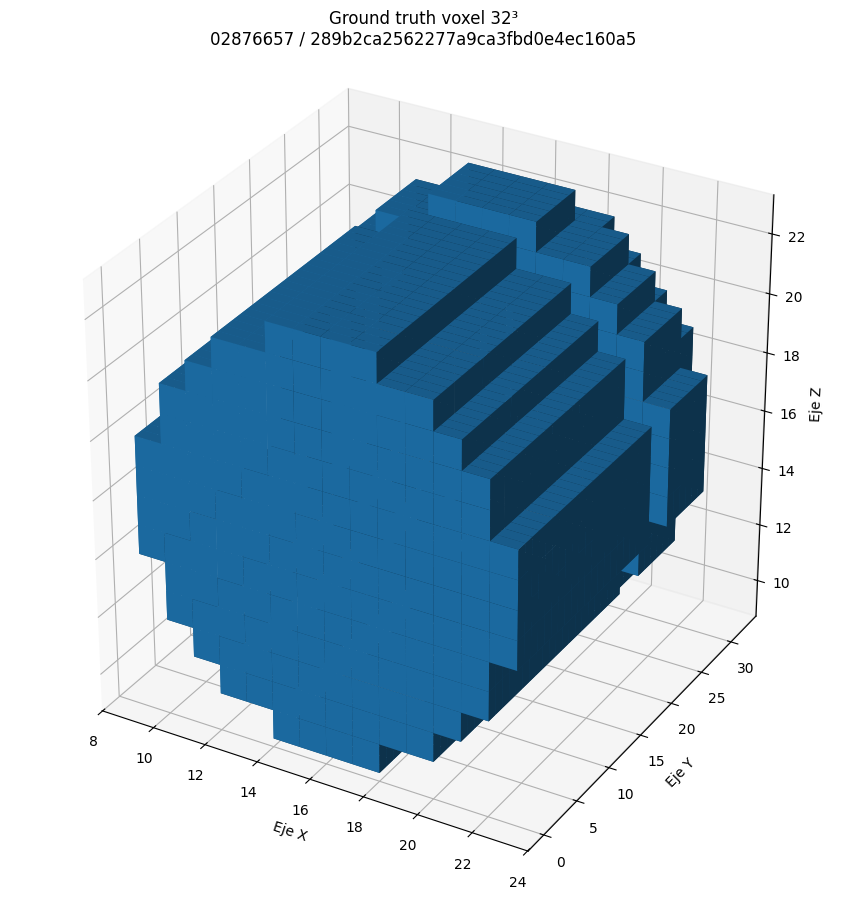

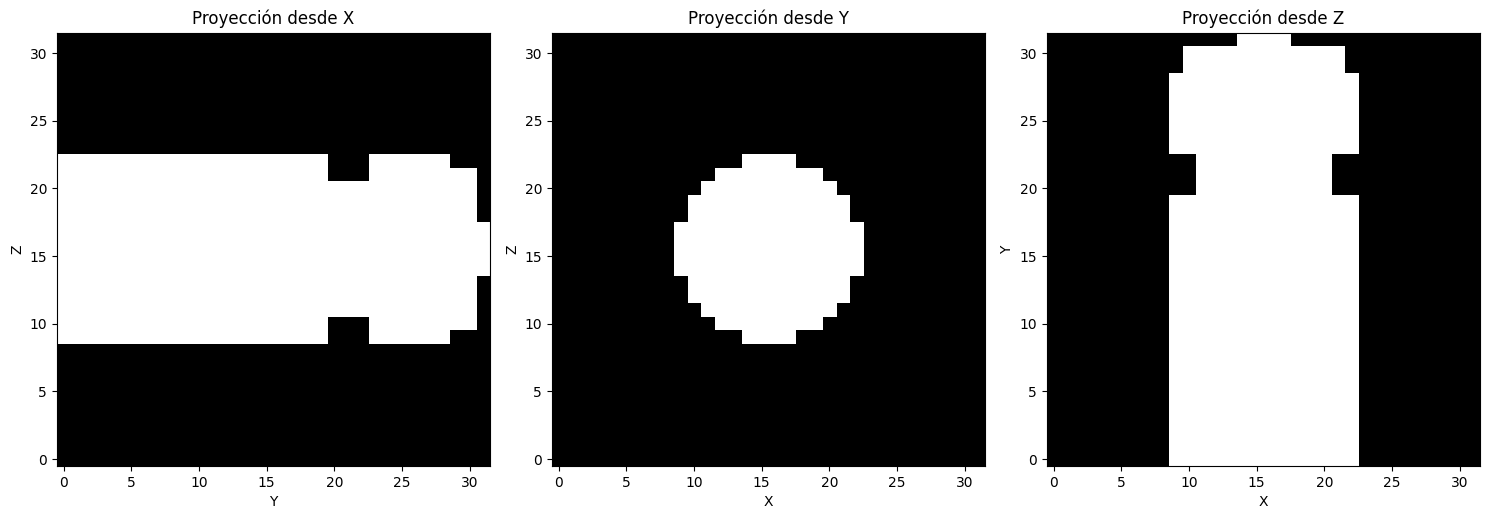

In [ ]:
seleccion = visualizar_binvox_aleatorio()